# Least Squares Regression using Pseudoinverse

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Generate synthetic data

In [2]:
np.random.seed(0)
n = 100
X = np.random.rand(n, 1) * 10  # 100 points in [0,10)
y_true = 3 * X.squeeze() + 5   # underlying true linear relationship
y = y_true + np.random.randn(n) * 2  # add noise


## 2. Add bias (intercept) term

In [3]:
X_design = np.hstack((np.ones((n, 1)), X))  # shape (n, 2)


## 3. Compute pseudoinverse and solve for coefficients

In [4]:
X_pinv = np.linalg.pinv(X_design)
w = X_pinv @ y  # shape (2,)

print("Estimated coefficients:")
print(f"Intercept: {w[0]:.3f}, Slope: {w[1]:.3f}")


Estimated coefficients:
Intercept: 5.444, Slope: 2.987


## 4. Plot the data and the regression line

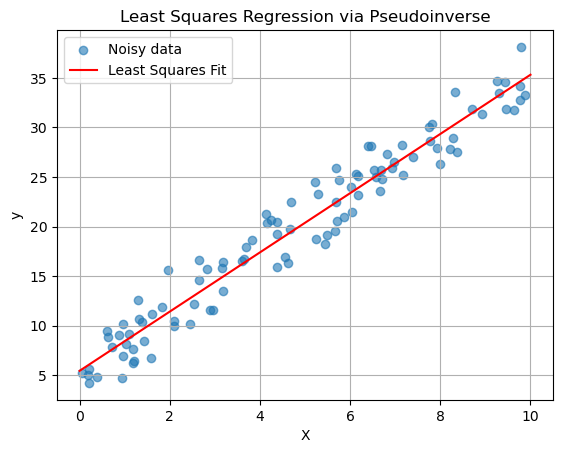

In [5]:
x_vals = np.linspace(0, 10, 100)
X_plot = np.vstack([np.ones_like(x_vals), x_vals]).T
y_pred = X_plot @ w

plt.scatter(X[:, 0], y, label='Noisy data', alpha=0.6)
plt.plot(x_vals, y_pred, color='red', label='Least Squares Fit')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Least Squares Regression via Pseudoinverse")
plt.grid(True)
plt.show()


## 5. Comparison with NumPy's `lstsq`

In [6]:
w_lstsq, *_ = np.linalg.lstsq(X_design, y, rcond=None)
print("\nComparison with np.linalg.lstsq:")
print(f"Intercept: {w_lstsq[0]:.3f}, Slope: {w_lstsq[1]:.3f}")



Comparison with np.linalg.lstsq:
Intercept: 5.444, Slope: 2.987
